In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("marketing_campaign_c.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,4/9/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,8/3/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/8/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/2/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/1/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df_clean = df.copy()

df_clean["Age"] = 2014 - df_clean["Year_Birth"]

df_clean = df_clean[(df_clean["Age"] >= 18) & (df_clean["Age"] <= 90)]

df_clean.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,4/9/2012,58,635,...,0,0,0,0,0,0,3,11,1,57
1,2174,1954,Graduation,Single,46344.0,1,1,8/3/2014,38,11,...,0,0,0,0,0,0,3,11,0,60
2,4141,1965,Graduation,Together,71613.0,0,0,21/8/2013,26,426,...,0,0,0,0,0,0,3,11,0,49
3,6182,1984,Graduation,Together,26646.0,1,0,10/2/2014,26,11,...,0,0,0,0,0,0,3,11,0,30
4,5324,1981,PhD,Married,58293.0,1,0,19/1/2014,94,173,...,0,0,0,0,0,0,3,11,0,33


In [ ]:
df_rfm = df_clean.copy()
df_rfm["Frequency"] = (
    df_rfm["NumWebPurchases"] +
    df_rfm["NumCatalogPurchases"] +
    df_rfm["NumStorePurchases"]
)
df_rfm["Monetary"] = (
    df_rfm["MntWines"] +
    df_rfm["MntFruits"] +
    df_rfm["MntMeatProducts"] +
    df_rfm["MntFishProducts"] +
    df_rfm["MntSweetProducts"] +
    df_rfm["MntGoldProds"]
)
rfm = df_rfm[["Recency", "Frequency", "Monetary", "Response"]]

rfm.head()

,Recency,Frequency,Monetary,Response
0,58,22,1617,1
1,38,4,27,0
2,26,20,776,0
3,26,6,53,0
4,94,14,422,0


In [5]:
from sklearn.model_selection import train_test_split

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

supervised_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
}

In [ ]:
from imblearn.over_sampling import SMOTE

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Response"]

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

print("Before balancing:")
print(y.value_counts())
print("\nAfter balancing:")
print(pd.Series(y_balanced).value_counts())

Before balancing:
Response
0    1903
1     334
Name: count, dtype: int64

After balancing:
Response
1    1903
0    1903
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Supervised models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print("Model Performance Summary (10-Fold Cross-Validation)")
print("="*60)

for name, model in models.items():
    
    accuracy = cross_val_score(model, X, y, cv=10, scoring="accuracy")
    precision = cross_val_score(model, X, y, cv=10, scoring="precision_macro")
    recall = cross_val_score(model, X, y, cv=10, scoring="recall_macro")
    f1 = cross_val_score(model, X, y, cv=10, scoring="f1_macro")

    print(f"\n{name}:")
    print(f" - Mean Accuracy: {accuracy.mean():.4f}")
    print(f" - Mean Precision: {precision.mean():.4f}")
    print(f" - Mean Recall: {recall.mean():.4f}")
    print(f" - Mean F1-Score: {f1.mean():.4f}")
    print("-"*60)

Model Performance Summary (10-Fold Cross-Validation)

Logistic Regression:
 - Mean Accuracy: 0.8596
 - Mean Precision: 0.7421
 - Mean Recall: 0.5632
 - Mean F1-Score: 0.5751
------------------------------------------------------------

Random Forest:
 - Mean Accuracy: 0.8436
 - Mean Precision: 0.6704
 - Mean Recall: 0.5982
 - Mean F1-Score: 0.6157
------------------------------------------------------------

Gradient Boosting:
 - Mean Accuracy: 0.8507
 - Mean Precision: 0.7013
 - Mean Recall: 0.5790
 - Mean F1-Score: 0.5966
------------------------------------------------------------

Decision Tree:
 - Mean Accuracy: 0.7948
 - Mean Precision: 0.5992
 - Mean Recall: 0.5955
 - Mean F1-Score: 0.5958
------------------------------------------------------------

KNN:
 - Mean Accuracy: 0.8413
 - Mean Precision: 0.6504
 - Mean Recall: 0.5784
 - Mean F1-Score: 0.5921
------------------------------------------------------------


In [12]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled[:5]

array([[ 0.30727179,  1.31254342,  1.6806492 ],
       [-0.38358403, -1.18596144, -0.96183763],
       [-0.79809753,  1.03493177,  0.28295648],
       [-0.79809753, -0.90834979, -0.91862715],
       [ 1.55081228,  0.20209681, -0.30537077]])

In [14]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# Dictionary to store scores
cluster_results = {}

# =========================
# Gaussian Mixture Model
# =========================
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_clusters = gmm.fit_predict(rfm_scaled)

rfm.loc[:, "GMM_Cluster"] = gmm_clusters

gmm_score = silhouette_score(rfm_scaled, gmm_clusters)
cluster_results["Gaussian Mixture"] = gmm_score


# =========================
# Hierarchical Clustering
# =========================
hc = AgglomerativeClustering(n_clusters=3)
hc_clusters = hc.fit_predict(rfm_scaled)

rfm.loc[:, "HC_Cluster"] = hc_clusters

hc_score = silhouette_score(rfm_scaled, hc_clusters)
cluster_results["Hierarchical"] = hc_score


# =========================
# DBSCAN
# =========================
db = DBSCAN(eps=0.5, min_samples=5)
db_clusters = db.fit_predict(rfm_scaled)

rfm.loc[:, "DBSCAN_Cluster"] = db_clusters

if len(set(db_clusters)) > 1:
    db_score = silhouette_score(rfm_scaled, db_clusters)
    cluster_results["DBSCAN"] = db_score
else:
    cluster_results["DBSCAN"] = None


# =========================
# K-Means
# =========================
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(rfm_scaled)

rfm.loc[:, "KMeans_Cluster"] = kmeans_clusters

kmeans_score = silhouette_score(rfm_scaled, kmeans_clusters)
cluster_results["K-Means"] = kmeans_score


# =========================
# Print Results
# =========================
print("Clustering Performance Comparison (Silhouette Score)")
print("="*60)

for model, score in cluster_results.items():
    if score is not None:
        print(f"{model}: {score:.4f}")
    else:
        print(f"{model}: Silhouette Score not available")

C:\Users\Asus\AppData\Local\Temp\ipykernel_12452\1293928514.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm.loc[:, "HC_Cluster"] = hc_clusters
C:\Users\Asus\AppData\Local\Temp\ipykernel_12452\1293928514.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm.loc[:, "DBSCAN_Cluster"] = db_clusters


Clustering Performance Comparison (Silhouette Score)
Gaussian Mixture: 0.3823
Hierarchical: 0.3851
DBSCAN: 0.2971
K-Means: 0.3950


C:\Users\Asus\AppData\Local\Temp\ipykernel_12452\1293928514.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm.loc[:, "KMeans_Cluster"] = kmeans_clusters


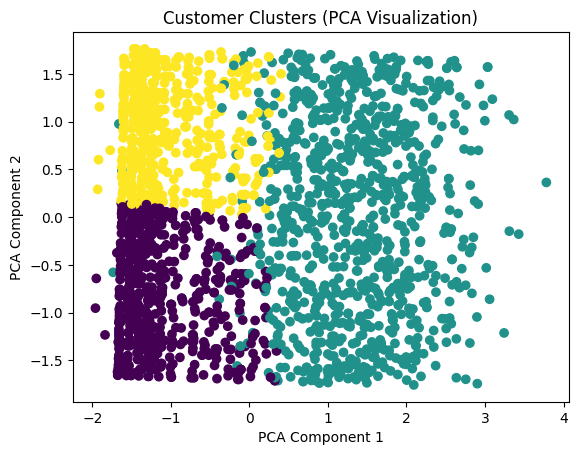

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=gmm_clusters,
    cmap="viridis"
)

plt.title("Customer Clusters (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()